# 🎓 Histogramas y Mejora de Contraste

En esta sesión aprenderemos a analizar la distribución de luz de una imagen. Esto es vital para corregir fotos muy oscuras, muy claras o con poco contraste antes de procesarlas.

### 🎯 Objetivos de Aprendizaje
1.  Visualizar **Histogramas** para entender la exposición.
2.  Aplicar **Ecualización de Histograma** global.
3.  Usar **CLAHE** para mejorar detalles en zonas específicas sin quemar la imagen.

---

## 1. ¿Qué es un Histograma?

Un histograma es una gráfica que nos dice cuántos píxeles hay de cada intensidad (de 0 a 255). 
* Si los picos están a la **izquierda**, la imagen es oscura.
* Si están a la **derecha**, la imagen es muy brillante.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar imagen en escala de grises para simplificar
img = cv2.imread('paisaje_oscuro.jpg', 0) 

# 2. Calcular histograma
# [img]: lista de imagenes, [0]: canal, None: sin mascara, [256]: niveles, [0,256]: rango
hist = cv2.calcHist([img], [0], None, [256], [0, 256])

# 3. Visualizar
plt.figure(figsize=(10,4))
plt.subplot(1,2,1), plt.imshow(img, cmap='gray'), plt.title("Imagen Original")
plt.subplot(1,2,2), plt.plot(hist), plt.title("Histograma (Frecuencia de Intensidad)")
plt.xlim([0, 256])
plt.show()

## 2. Ecualización Global vs CLAHE

La ecualización "estira" el histograma para que use todo el rango disponible. Sin embargo, a veces crea ruido. Para eso usamos **CLAHE** (Contrast Limited Adaptive Histogram Equalization).

In [ ]:
# Ecualización Global (Simple)
equ = cv2.equalizeHist(img)

# CLAHE (Adaptativo - Mejor para detalles)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
res_clahe = clahe.apply(img)

# Comparar
plt.figure(figsize=(15,5))
plt.subplot(1,3,1), plt.imshow(img, cmap='gray'), plt.title("Original")
plt.subplot(1,3,2), plt.imshow(equ, cmap='gray'), plt.title("Ecualización Global")
plt.subplot(1,3,3), plt.imshow(res_clahe, cmap='gray'), plt.title("CLAHE (Adaptativo)")
plt.show()

### 🚀 Proyecto Aplicado: "Mejora de Cámaras de Seguridad"

Imagina que tienes una cámara de vigilancia nocturna donde casi no se ve nada. Vamos a crear una función que mejore la visibilidad automáticamente.

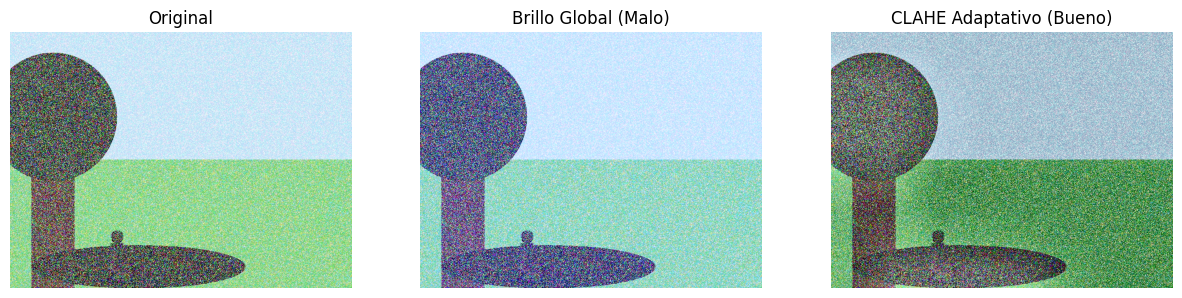

In [2]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar la imagen de prueba que creamos
img = cv2.imread('persona_sombra.jpg')

# 2. MÉTODO TRADICIONAL (MALO): Subir brillo global sumando un valor
# Esto "quema" las luces blancas y las vuelve planas.
img_brillo_global = cv2.add(img, np.array([50.0])) 

# 3. MÉTODO CLAHE (BUENO): Mejora adaptativa local
def mejorar_visibilidad(frame_bgr):
    lab = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    
    # Aplicamos CLAHE: El 'mago' que rescata las sombras
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    l_mejorada = clahe.apply(l)
    
    lab_final = cv2.merge((l_mejorada, a, b))
    return cv2.cvtColor(lab_final, cv2.COLOR_LAB2BGR)

img_clahe = mejorar_visibilidad(img)

# --- 4. Visualización de Resultados ---
titulos = ['Original', 'Brillo Global (Malo)', 'CLAHE Adaptativo (Bueno)']
imagenes = [img, img_brillo_global, img_clahe]

plt.figure(figsize=(15, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    # Convertimos de BGR a RGB para Matplotlib
    plt.imshow(cv2.cvtColor(imagenes[i], cv2.COLOR_BGR2RGB))
    plt.title(titulos[i])
    plt.axis('off')

plt.show()

## WebCam

cap.read(): Retorna un booleano (ret) que dice si la cámara funciona, y el fotograma real (frame).

np.hstack(): Es fundamental en visión artificial para depurar. Nos permite ver el efecto de nuestro código comparándolo con la realidad en la misma ventana.

cv2.waitKey(1): En video, el número debe ser 1 (espera 1 milisegundo). Si pusieras 0, el video se congelaría en el primer cuadro esperando que presiones una tecla.

🚀 Variantes y Retos para ti:
Visión de "Película de Terror": Intenta aplicar el CLAHE pero, en lugar de volver a unir los canales a y b, muestra solo el canal l_mejorado. Se verá como una cámara de seguridad infrarroja.

Control dinámico: ¿Podrías intentar que el clipLimit cambie si presionas las flechas del teclado? (Usa variables para el valor de 3.0).


In [ ]:
import cv2
import numpy as np

# 1. Inicializar la captura de video (0 es la webcam integrada)
cap = cv2.VideoCapture(0)

# 2. Crear el objeto CLAHE una sola vez (fuera del bucle para ahorrar memoria)
# clipLimit=3.0: Intensidad del contraste.
# tileGridSize=(8,8): Divide el cuadro en 64 sectores de análisis.
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))

print("Presiona 'q' para salir...")

while True:
    # Capturar fotograma por fotograma
    ret, frame = cap.read()
    if not ret:
        break

    # --- PROCESO DE MEJORA ---
    
    # A. Convertimos a LAB para no arruinar los colores
    lab = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    
    # B. Aplicamos el filtro al canal L (Luminosidad)
    l_mejorada = clahe.apply(l)
    
    # C. Volvemos a unir y convertir a BGR para mostrar en pantalla
    #lab_final = cv2.merge((l_mejorada, a, b))
    #frame_mejorado = cv2.cvtColor(lab_final, cv2.COLOR_LAB2BGR)

    # --- VISUALIZACIÓN ---
    
    # Unimos los dos cuadros (Original y Mejorado) lado a lado
    # np.hstack pone las matrices de imagen una junto a la otra
    #comparativa = np.hstack((frame, frame_mejorado))

    # Título de la ventana
    # cv2.imshow('Webcam: Izquierda (Original) | Derecha (CLAHE Adaptativo)', comparativa)


    # Opción 1: Mostrar el canal L en blanco y negro (Grayscale)
    # No necesitamos unir canales, se ve como una foto artística en B/N
    cv2.imshow('1. Canal L Mejorado (Blanco y Negro)', l_mejorada)

    # Opción 2: Efecto "Visión Nocturna" (ColorMap)
    # Le aplicamos un tinte verde al canal L para que parezca de película
    vision_nocturna = cv2.applyColorMap(l_mejorada, cv2.COLORMAP_WINTER)
    cv2.imshow('2. Efecto Visión Nocturna', vision_nocturna)
    # 3. Condición de salida: Presionar la tecla 'q'
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# 4. Liberar la cámara y cerrar ventanas
cap.release()
cv2.destroyAllWindows()

Presiona 'q' para salir...
